In [1]:
import os
import time
import pickle
import multiprocessing

os.environ['OPENMDAO_REQUIRE_MPI'] = 'false'  # Suppress OpenMDAO MPI import warnings

from open_turb_arch.architecting import *
from open_turb_arch.architecting.metrics import *
from open_turb_arch.architecting.turbofan import *
from open_turb_arch.evaluation.analysis import *

from open_turb_arch.architecting.pymoo import *
from pymoo.optimize import minimize
from pymoo.algorithms.nsga2 import NSGA2
from pymoo.operators.sampling.latin_hypercube_sampling import LatinHypercubeSampling

In [2]:
def get_architecting_problem():
    analysis_problem = AnalysisProblem(
        design_condition=DesignCondition(
            # mach=1e-6,  # Mach number [-]
            # alt=0,  # Altitude [ft]
            # thrust=150e3,  # Thrust [N]
            # turbine_in_temp=1450,  # Turbine inlet temperature [C]
            # bleed_offtake=0.5,  # Extraction bleed offtake [kg/s]
            # power_offtake=37.5e3,  # Power offtake [W]
            balancer=DesignBalancer(init_turbine_pr=10, init_mass_flow=400, init_extraction_bleed_frac=0.02),
            
            # mach=0.78,  # Mach number [-]
            # alt=10668 * 3.28084,  # Altitude [ft]
            # thrust=24900,  # Thrust [N]
            # d_temp=10.0,  # Temperature difference to standard atmosphere [K]
            # turbine_in_temp=1800 - 273.15,  # Turbine inlet temperature [C]
            # bleed_offtake=0,  # Extraction bleed offtake [kg/s]
            # power_offtake=50000,  # Power offtake [W]
            
            mach=0.78,  # Mach number [-]
            alt=10668 * 3.28084,  # Altitude [ft]
            thrust=24900,  # Thrust [N]
            d_temp=0.,  # Temperature difference to standard atmosphere [K]
            turbine_in_temp=1800 - 273.15,  # Turbine inlet temperature [C]
            bleed_offtake=0,  # Extraction bleed offtake [kg/s]
            power_offtake=50000,  # Power offtake [W]
        ),
        
        evaluate_conditions=[
            # EvaluateCondition(
            #     name_='Cruise',
            #     mach=0.78,  # Mach number [-]
            #     alt=10668 * 3.28084,  # Altitude [ft]
            #     thrust=20400,  # Thrust [N]
            #     balancer=OffDesignBalancer(
            #         init_bpr=8.0,
            #         init_shaft_rpm=400.,
            #         init_mass_flow=200.,
            #         init_far=.025,
            #         init_extraction_bleed_frac=0.01
            #     ),
            #     d_temp=0.,  # Temperature difference to standard atmosphere [K]
            #     bleed_offtake=0.,  # Extraction bleed offtake [kg/s]
            #     power_offtake=50000,  # Power offtake [W]
            # ),
            # EvaluateCondition(
            #     name_='MCL1',
            #     mach=0.71,  # Mach number [-]
            #     alt=9449 * 3.28084,  # Altitude [ft]
            #     thrust=27200,  # Thrust [N]
            #     balancer=OffDesignBalancer(
            #         init_bpr=3.8,
            #         init_shaft_rpm=7500.,
            #         init_mass_flow=100.,
            #         init_far=.025,
            #         init_extraction_bleed_frac=0.01
            #     ),
            #     d_temp=0.,  # Temperature difference to standard atmosphere [K]
            #     bleed_offtake=0.,  # Extraction bleed offtake [kg/s]
            #     power_offtake=50000,  # Power offtake [W]
            # ),
            # EvaluateCondition(
            #     name_='MCL0',
            #     mach=0.45,  # Mach number [-]
            #     alt=3048 * 3.28084,  # Altitude [ft]
            #     thrust=58000,  # Thrust [N]
            #     balancer=OffDesignBalancer(
            #         init_bpr=3.8,
            #         init_shaft_rpm=7500.,
            #         init_mass_flow=100.,
            #         init_far=.025,
            #         init_extraction_bleed_frac=0.01
            #     ),
            #     d_temp=0.,  # Temperature difference to standard atmosphere [K]
            #     bleed_offtake=0.,  # Extraction bleed offtake [kg/s]
            #     power_offtake=50000,  # Power offtake [W]
            # ),
            # EvaluateCondition(
            #     name_='TakeOff',
            #     mach=0.25,  # Mach number [-]
            #     alt=1e-6,  # Altitude [ft]
            #     thrust=105000,  # Thrust [N]
            #     balancer=OffDesignBalancer(
            #         init_bpr=8.5,
            #         init_shaft_rpm=8000.,
            #         init_mass_flow=200.,
            #         init_far=.025,
            #         init_extraction_bleed_frac=0.01
            #     ),
            #     d_temp=0.,  # Temperature difference to standard atmosphere [K]
            #     bleed_offtake=0.,  # Extraction bleed offtake [kg/s]
            #     power_offtake=50000,  # Power offtake [W]
            # ),
        ]
    )

    return ArchitectingProblem(
        analysis_problem=analysis_problem,
        choices=[
            # FanChoice(),
            # ShaftChoice(),
            # GearboxChoice(),
            # NozzleMixingChoice(),
            # OfftakesChoice(),
            
            FanChoice(fix_include_fan=True), 
            CRTFChoice(fix_include_crtf=False),
            ShaftChoice(
                fixed_number_shafts=2,    
                ),
            GearboxChoice(fix_include_gear=False),
            AfterburnerChoice(fix_include_afterburner=False),
            ITBChoice(fix_include_itb=False),     
            CoolingBleedChoice(
                # Detail: 
                # recirculating: inter-bleed HPC-burner to LPC:                         0%
                # handling bleed: inter-bleed HPC-LPC (extraction bleed)                0%
                # overboard bleed: intra-bleed HPC (extraction bleed)                   0.5%
                # LPT cooling: intra-bleed HPC to LPT                                   2%
                # HP leakage (a): inter-bleed HPC-burner (extraction bleed)             0%
                # NGV cooling (b): inter-bleed HPC-burner to HPT (stator part)          5%
                # HPT cooling (c): inter-bleed HPC-burner to HPT (rotor part)           5%
                # HP leak to LPT exit: inter-bleed HPC-burner to LPT                    0%
                # Translation: LPC to IPC
                
                # # Inter-bleed HPC-burner
                # fix_eb_hb_total = 0.10,  # Fix the total cooling bleed portion of the inter-bleed between the HPC and burner
                # fix_eb_hbi_frac_w = 0,  # Fix the cooling bleed portion of the IPT as target of the inter-bleed between the HPC and burner
                # fix_eb_hbl_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the inter-bleed between the HPC and burner

                # # Inter-bleed IPC-HPC
                # fix_eb_ih_total = 0,  # Fix the total cooling bleed portion of the inter-bleed between the IPC and HPC
                # fix_eb_ihi_frac_w = 0,  # Fix the cooling bleed portion of the IPT as target of the inter-bleed between the IPC and HPC
                # fix_eb_ihl_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the inter-bleed between the IPC and HPC

                # # Inter-bleed LPC-IPC
                # fix_eb_li_total = 0,  # Fix the total cooling bleed portion of the inter-bleed between the LPC and IPC
                # fix_eb_lii_frac_w = 0,  # Fix the cooling bleed portion of the IPT as target of the inter-bleed between the LPC and IPC
                # fix_eb_lil_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the inter-bleed between the LPC and IPC

                # # Intra-bleed HPC
                # fix_ab_hpc_total = 0.02,  # Fix the total cooling bleed portion of the HPC intra-bleed
                # fix_ab_hi_frac_w = 1,  # Fix the cooling bleed portion of the IPT as target of the HPC intra-bleed
                # fix_ab_hl_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the HPC intra-bleed

                # # Intra-bleed IPC
                # fix_ab_ipc_total = 0,  # Fix the total cooling bleed portion of the IPC intra-bleed
                # fix_ab_ii_frac_w = 0,  # Fix the cooling bleed portion of the IPT as target of the IPC intra-bleed
                # fix_ab_il_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the IPC intra-bleed

                # # Intra-bleed LPC
                # fix_ab_lpc_total = 0,  # Fix the total cooling bleed portion of the LPC intra-bleed
                # fix_ab_li_frac_w = 0,  # Fix the cooling bleed portion of the IPT as target of the LPC intra-bleed
                # fix_ab_ll_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the LPC intra-bleed
            ),
            NozzleMixingChoice(fix_include_mixing=False),       # no nozzle mixing
            IntercoolerChoice(fix_include_ic=False),        # no intercooler   
            OfftakesChoice(
                fix_power_offtake_location=1, # 1: HPC, 2: IPC, 3: LPC
                fix_bleed_offtake_location=1, # 1: HPC, 2: IPC, 3: LPC
            ), 
        ],
        objectives=[
            TSFCMetric(),
            WeightMetric(),
            NoiseMetric(),
        ],
        constraints=[
            # JetMachMetric(max_jet_mn=1.),
        ],
        metrics=[
            TSFCMetric(),
            WeightMetric(),
            LengthMetric(),
            DiameterMetric(),
            NOxMetric(),
            NoiseMetric(),
            JetMachMetric(),
            BurnerInletTemperatureMetric(),
        ],
    )


def get_pymoo_architecting_problem():
    return PymooArchitectingProblem(get_architecting_problem())


In [3]:
# Check current folder
import os
print("Current folder:", os.getcwd())

# Change to current workspace folderif os.path.basename(os.getcwd()) != 'OpenTurbofanArchitecting':
os.chdir('../../../../')  # Change to workspace folder
print("Changed folder to:", os.getcwd())

Current folder: c:\Users\hafiz\University\ISAE-SUPAERO\4. Research Project\Work\OpenTurbofanArchitecting\open_turb_arch\tests\examples
Changed folder to: c:\Users\hafiz\University\ISAE-SUPAERO\4. Research Project\Work


# Single-Objective Optimization

In [4]:
architecting_problem = get_architecting_problem()

architecting_problem.print_results = True
architecting_problem.verbose = True
architecting_problem._max_iter = 30
architecting_problem.save_results_folder = 'results_latest'  # Insert folder name to save results
architecting_problem.save_results_combined = True

# result = minimize(problem, algorithm, termination=('n_eval', 198), verbose=True, save_history=True)
# elapsed = time.time() - t

# Read results from file
with open(architecting_problem.save_results_folder+'/pymoo_algo_results.pkl', 'rb') as fp:
    result = pickle.load(fp)


In [5]:
result.__dict__.keys()

dict_keys(['opt', 'success', 'message', 'problem', 'pf', 'algorithm', 'pop', 'X', 'F', 'CV', 'G', 'start_time', 'end_time', 'exec_time', 'history'])

In [6]:
free_dv_names = [des_var.name for des_var in architecting_problem.free_opt_des_vars]
print('Free design variable names: %r' % free_dv_names)

# Get design variable types from class names
free_dv_types = [des_var.__class__.__name__ for des_var in architecting_problem.free_opt_des_vars]
print('Free design variable types: %r' % free_dv_types)
print('Unique free design variable types: %r' % set(free_dv_types))

Free design variable names: ['bpr', 'fpr', 'opr', 'pr_compressor_ip', 'pr_compressor_lp', 'rpm_shaft_hp', 'rpm_shaft_ip', 'rpm_shaft_lp', 'gear_ratio', 'far', 'far', 'eb_hb_total', 'eb_hbi_frac_w', 'eb_hbl_frac_w', 'eb_ih_total', 'eb_ihi_frac_w', 'eb_ihl_frac_w', 'eb_li_total', 'eb_lii_frac_w', 'eb_lil_frac_w', 'ab_hpc_total', 'ab_hi_frac_w', 'ab_hl_frac_w', 'ab_ipc_total', 'ab_ii_frac_w', 'ab_il_frac_w', 'ab_lpc_total', 'ab_li_frac_w', 'ab_ll_frac_w', 'ic_location', 'radius', 'length', 'number']
Free design variable types: ['ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVari

In [7]:
# Create a dictionary for the best solution with design variable names as keys and their corresponding values from the optimization result
dict_result = dict(zip(free_dv_names, result.X))

In [8]:

import pandas as pd

# obj_names = ['TSFC']
met_values_names = ['TSFC', 'Weight', 'Length', 'Diameter', 'NOx', 'Noise', 'JetMach']

results_combined_df = pd.DataFrame(columns=free_dv_names + met_values_names)

# Read add files in architecting_problem.save_results_folder
with open(architecting_problem.save_results_folder+'/results_combined.txt', 'r') as f:
    # # Read first line
    # line = f.readline()
    # Loop through lines
    for line in f:
        # Read line as dictionary
        import ast
        
        try:
            dict_line = ast.literal_eval(line)
            
            dv_line = dict_line['design_vector']
            # obj_values = dict_line['obj_values']
            met_values = dict_line['met_values']
            
            result_array = dv_line + met_values
            
            # Convert to dataframe and append to results_combined_df
            df_line = pd.DataFrame([result_array], columns=free_dv_names + met_values_names)
            results_combined_df = pd.concat([results_combined_df, df_line], ignore_index=True)
        except Exception as e:
            continue
    
results_combined_df

,bpr,fpr,opr,pr_compressor_ip,pr_compressor_lp,rpm_shaft_hp,rpm_shaft_ip,rpm_shaft_lp,gear_ratio,far,...,radius,length,number,TSFC,Weight,Length,Diameter,NOx,Noise,JetMach
0,12.469925,1.393848,48.573321,0.444613,0.508635,18847.056102,9019.812952,15106.740512,1.998511,0.029819,...,0.045204,0.295675,130,15.346355,2050.402533,3.050343,2.694277,31.054356,104.142494,1.00000
1,10.153243,1.706680,16.198817,0.771936,0.466641,19727.362086,7429.627703,3997.523437,1.115306,0.039337,...,0.047802,0.218876,228,17.450258,1509.136136,2.915087,2.491685,5.754456,106.249340,0.73689
2,6.637482,1.247291,6.199196,0.473170,0.314034,11668.252422,5056.515208,2453.449851,1.259589,0.023685,...,0.026803,0.029380,134,28.313327,1228.010546,3.036323,2.486550,1.750197,109.127017,1.00000
3,3.617602,1.452629,53.098584,0.672906,0.754494,3444.378930,18931.382665,6586.254405,3.740574,0.045239,...,0.044585,0.487712,102,20.350109,988.873046,2.790905,2.038923,35.848058,103.634388,1.00000
4,9.679614,1.484807,15.532220,0.420347,0.689847,8893.468664,1485.999823,16363.765473,1.327066,0.011326,...,0.027973,0.440250,234,18.044958,1520.095159,2.962443,2.528875,5.529370,106.648901,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,12.383723,1.481684,58.938297,0.219015,0.000000,7067.649861,1773.162872,10500.000000,3.000000,0.025000,...,0.030000,0.255000,0,14.974844,1911.361590,2.943423,2.575170,42.445237,104.372158,1.00000
338,12.383723,1.481684,58.938297,0.219015,0.000000,7067.649861,1773.162872,10500.000000,3.000000,0.025000,...,0.030000,0.255000,0,14.974844,1911.361590,2.943423,2.575170,42.445237,104.372158,1.00000
339,12.383723,1.481684,58.938297,0.219015,0.000000,7067.649861,1773.162872,10500.000000,3.000000,0.025000,...,0.030000,0.255000,0,14.974844,1911.361590,2.943423,2.575170,42.445237,104.372158,1.00000
340,12.383723,1.481684,58.938297,0.219015,0.000000,7067.649861,1773.162872,10500.000000,3.000000,0.025000,...,0.030000,0.255000,0,14.974844,1911.361590,2.943423,2.575170,42.445237,104.372158,1.00000


In [9]:
results_combined_df_filtered = results_combined_df[results_combined_df['rpm_shaft_hp'] > results_combined_df['rpm_shaft_ip']]
results_combined_df_lasts = results_combined_df_filtered.tail(40)

In [10]:
results_combined_df_lasts_best = results_combined_df_lasts.nsmallest(1, 'TSFC')
results_combined_df_lasts_best.to_dict()

C:\Users\hafiz\AppData\Local\Temp\ipykernel_62260\2255074765.py:2: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  results_combined_df_lasts_best.to_dict()


{'bpr': {309: 12.383723156909081},
 'fpr': {309: 1.481683726116061},
 'opr': {309: 58.93829717456455},
 'pr_compressor_ip': {309: 0.21901465412816748},
 'pr_compressor_lp': {309: 0.1},
 'rpm_shaft_hp': {309: 7067.649861383017},
 'rpm_shaft_ip': {309: 1773.1628722840915},
 'rpm_shaft_lp': {309: 10500.0},
 'gear_ratio': {309: 3.0},
 'far': {309: 0.025},
 'eb_hb_total': {309: 0.014797623414826336},
 'eb_hbi_frac_w': {309: 0.0},
 'eb_hbl_frac_w': {309: 0.0},
 'eb_ih_total': {309: 0.09749230568381187},
 'eb_ihi_frac_w': {309: 0.0},
 'eb_ihl_frac_w': {309: 0.0},
 'eb_li_total': {309: 0.0},
 'eb_lii_frac_w': {309: 0.0},
 'eb_lil_frac_w': {309: 0.0},
 'ab_hpc_total': {309: 0.01679292542356151},
 'ab_hi_frac_w': {309: 0.0},
 'ab_hl_frac_w': {309: 0.0},
 'ab_ipc_total': {309: 0.06939559703482323},
 'ab_ii_frac_w': {309: 0.0},
 'ab_il_frac_w': {309: 0.0},
 'ab_lpc_total': {309: 0.0},
 'ab_li_frac_w': {309: 0.0},
 'ab_ll_frac_w': {309: 0.0},
 'ic_location': {309: 0},
 'radius': {309: 0.03000000000

Text(0, 0.5, 'NOx [g/kg fuel]')

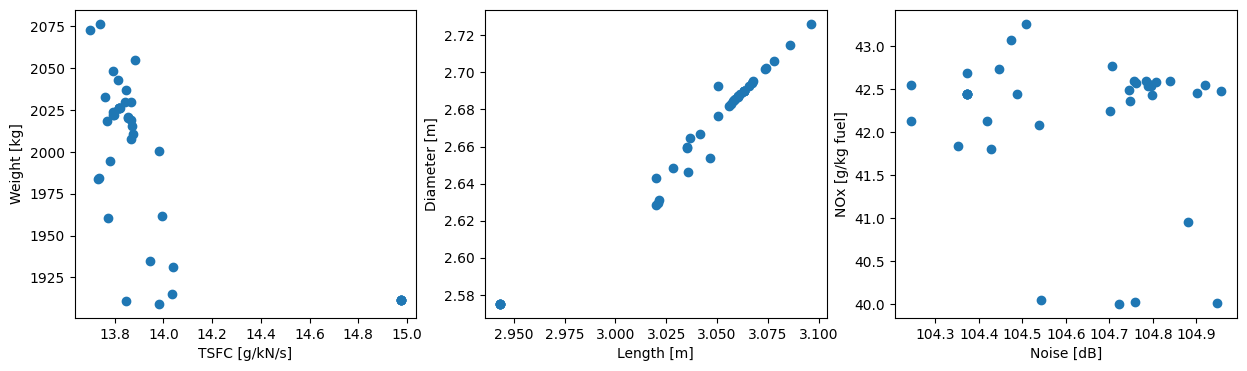

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 4), ncols=3)
ax[0].scatter(results_combined_df_lasts['TSFC'], results_combined_df_lasts['Weight'])
ax[0].set_xlabel('TSFC [g/kN/s]')
ax[0].set_ylabel('Weight [kg]')

ax[1].scatter(results_combined_df_lasts['Length'], results_combined_df_lasts['Diameter'])
ax[1].set_xlabel('Length [m]')
ax[1].set_ylabel('Diameter [m]')

ax[2].scatter(results_combined_df_lasts['Noise'], results_combined_df_lasts['NOx'])
ax[2].set_xlabel('Noise [dB]')
ax[2].set_ylabel('NOx [g/kg fuel]')



In [17]:
# def adjust_dv_type(dv, dv_type):
#     if dv_type == 'DiscreteDesignVariable':
#         return int(round(dv))
#     else:
#         return dv

In [18]:
# result_X_filtered = results_combined_df_lasts_best[free_dv_names].values

# for dv in result_X_filtered:
#     dv_adjusted = [adjust_dv_type(dv_i, dv_type) for dv_i, dv_type in zip(dv, free_dv_types)]
    
#     architecture, imputed_dv = architecting_problem.generate_architecture(dv_adjusted)
    
#     imputed_dv_dict = {des_var: value for des_var, value in zip(free_dv_names, imputed_dv)}
    
#     print('Imputed design vector: %r' % imputed_dv_dict)
    
#     design_vector, objectives, constraints, metrics = architecting_problem.evaluate(imputed_dv)
    
#     break

# Multi-Objective Optimization

In [19]:
architecting_problem = get_architecting_problem()

architecting_problem.print_results = True
architecting_problem.verbose = True
architecting_problem._max_iter = 30
architecting_problem.save_results_folder = 'results_latest_multi2'  # Insert folder name to save results
architecting_problem.save_results_combined = True

# result = minimize(problem, algorithm, termination=('n_eval', 198), verbose=True, save_history=True)
# elapsed = time.time() - t

# Read results from file
with open(architecting_problem.save_results_folder+'/pymoo_algo_results.pkl', 'rb') as fp:
    result = pickle.load(fp)


In [20]:
free_dv_names = [des_var.name for des_var in architecting_problem.free_opt_des_vars]
print('Free design variable names: %r' % free_dv_names)

# Get design variable types from class names
free_dv_types = [des_var.__class__.__name__ for des_var in architecting_problem.free_opt_des_vars]
print('Free design variable types: %r' % free_dv_types)
print('Unique free design variable types: %r' % set(free_dv_types))

Free design variable names: ['bpr', 'fpr', 'opr', 'pr_compressor_ip', 'pr_compressor_lp', 'rpm_shaft_hp', 'rpm_shaft_ip', 'rpm_shaft_lp', 'gear_ratio', 'far', 'far', 'eb_hb_total', 'eb_hbi_frac_w', 'eb_hbl_frac_w', 'eb_ih_total', 'eb_ihi_frac_w', 'eb_ihl_frac_w', 'eb_li_total', 'eb_lii_frac_w', 'eb_lil_frac_w', 'ab_hpc_total', 'ab_hi_frac_w', 'ab_hl_frac_w', 'ab_ipc_total', 'ab_ii_frac_w', 'ab_il_frac_w', 'ab_lpc_total', 'ab_li_frac_w', 'ab_ll_frac_w', 'ic_location', 'radius', 'length', 'number']
Free design variable types: ['ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVariable', 'ContinuousDesignVari

In [ ]:

architecting_problem.print_results = False
architecting_problem.verbose = False

Tt3_values = []

for design_vector in result.X:
    converted_design_vector = []
    for dv_i, dv_type in zip(design_vector, free_dv_types):
        if dv_type == 'DiscreteDesignVariable':
            dv_i = int(round(dv_i))
        converted_design_vector.append(dv_i)

    architecture, imputed_dv = architecting_problem.generate_architecture(converted_design_vector)

    imputed_dv_dict = {des_var: value for des_var, value in zip(free_dv_names, imputed_dv)}
    
    print('Imputed design vector: %r' % imputed_dv_dict)
    
    design_vector, objectives, constraints, metrics = architecting_problem.evaluate(imputed_dv)
    
    Tt3_values.append(metrics[-1])
    

Imputed design vector: {'bpr': 12.39227686640752, 'fpr': 1.4506071698495977, 'opr': 55.65242961845452, 'pr_compressor_ip': 0.28567976821456637, 'pr_compressor_lp': 0, 'rpm_shaft_hp': 11759.34887500935, 'rpm_shaft_ip': 10965.271828631136, 'rpm_shaft_lp': 10500.0, 'gear_ratio': 3.0, 'far': 0.025, 'eb_hb_total': 0.08604311500509115, 'eb_hbi_frac_w': 0.0, 'eb_hbl_frac_w': 0.0, 'eb_ih_total': 0.0770169418621345, 'eb_ihi_frac_w': 0.0, 'eb_ihl_frac_w': 0.0, 'eb_li_total': 0, 'eb_lii_frac_w': 0, 'eb_lil_frac_w': 0, 'ab_hpc_total': 0.009132804413288433, 'ab_hi_frac_w': 0.0, 'ab_hl_frac_w': 0.0, 'ab_ipc_total': 0.09425168407868012, 'ab_ii_frac_w': 0.0, 'ab_il_frac_w': 0.0, 'ab_lpc_total': 0, 'ab_li_frac_w': 0, 'ab_ll_frac_w': 0, 'ic_location': 0, 'radius': 0.030000000000000002, 'length': 0.255, 'number': 0}


In [ ]:
# Make a pandas dataframe of the results
import pandas as pd

df_results = pd.DataFrame(result.X, columns=free_dv_names)
df_results['TSFC'] = result.F[:, 0]
df_results['Weight'] = result.F[:, 1]
df_results['Noise'] = result.F[:, 2]
df_results['Tt3'] = Tt3_values

In [ ]:
expert_ref_dv = [
        3.11309372,     # BPR
        3.35042243,     # FPR
        82.93060324,    # OPR
        0.0819508208,             # % of IPC PR
        0.,              # % of LPC PR
        10000,          # HP Shaft RPM
        5000,           # IP Shaft RPM
        0,              # LP Shaft RPM
        0,              # Gear Ratio
        0,              # Afterburner FAR
        0,              # Inter Turbine Burner FAR
        0.15,           # Inter-bleed HPC-burner total cooling bleed portion
        0,              # Inter-bleed HPC-burner cooling bleed portion of the IPT as target
        0,          # Inter-bleed HPC-burner cooling bleed portion of the LPT as target
        0,          # Inter-bleed IPC-HPC total cooling bleed portion
        0,          # Inter-bleed IPC-HPC cooling bleed portion of the IPT as target
        0,          # Inter-bleed IPC-HPC cooling bleed portion of the LPT as target
        0,          # Inter-bleed LPC-IPC total cooling bleed portion
        0,          # Inter-bleed LPC-IPC cooling bleed portion of the IPT as target
        0,          # Inter-bleed LPC-IPC cooling bleed portion of the LPT as target
        0.01,       # HPC intra-bleed total cooling bleed portion
        1,          # HPC intra-bleed cooling bleed portion of the IPT as target
        0,          # HPC intra-bleed cooling bleed portion of the LPT as target
        0,          # IPC intra-bleed total cooling bleed portion
        0,          # IPC intra-bleed cooling bleed portion of the IPT as target
        0,          # IPC intra-bleed cooling bleed portion of the LPT as target
        0,          # LPC intra-bleed total cooling bleed portion
        0,          # LPC intra-bleed cooling bleed portion of the IPT as target
        0,          # LPC intra-bleed cooling bleed portion of the LPT as target
        0,          # Intercooler location
        0,          # Intercooler radius
        0,          # Intercooler length
        0,          # Number of intercooler pipes
    ]

architecture, imputed_dv = architecting_problem.generate_architecture(expert_ref_dv)

imputed_dv_dict = {des_var: value for des_var, value in zip(free_dv_names, imputed_dv)}

print('Imputed design vector: %r' % imputed_dv_dict)

expert_ref_design_vector, expert_ref_objectives, expert_ref_constraints, expert_ref_metrics = architecting_problem.evaluate(imputed_dv)

In [ ]:
expert_ref_dict

In [34]:
def bpr_classification(row):
    if row['bpr'] < 2:
        return 'BPR < 2'
    elif row['bpr'] < 5:
        return '2 <= BPR < 5'
    elif row['bpr'] < 10:
        return '5 <= BPR < 10'
    else:
        return 'BPR >= 10'

df_results['BPR_Class'] = df_results.apply(bpr_classification, axis=1)

def Tt3_classification(row):
    if row['Tt3'] < 600:
        return 'Tt3 < 600 K'
    elif row['Tt3'] < 700:
        return '600 <= Tt3 < 700 K'
    elif row['Tt3'] < 800:
        return '700 <= Tt3 < 800 K'
    elif row['Tt3'] < 900:
        return '800 <= Tt3 < 900 K'
    elif row['Tt3'] < 1000:
        return '900 <= Tt3 < 1000 K'
    else:
        return 'Tt3 >= 1000 K'
    
df_results['Tt3_Class'] = df_results.apply(Tt3_classification, axis=1)

Text(0, 0.5, 'Noise [dB]')

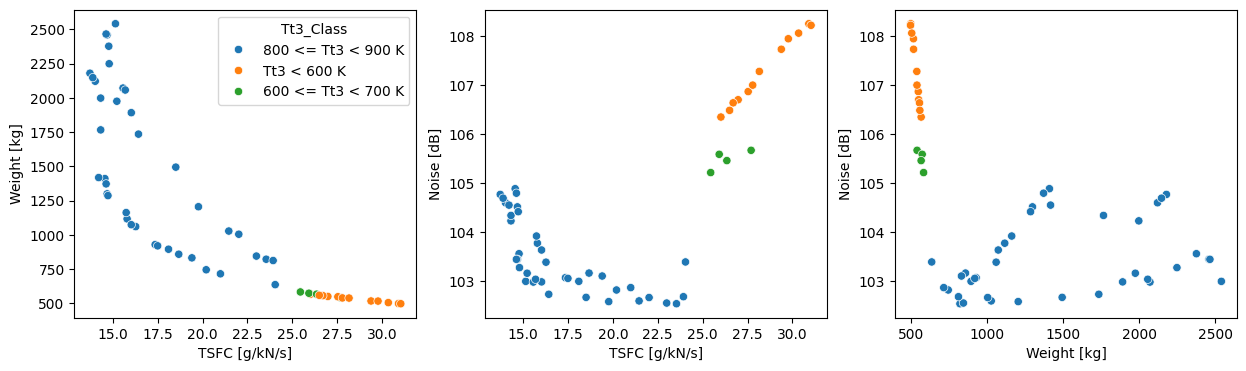

In [35]:
# Plot Pareto front
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(ncols=3, figsize=(15, 4))

df_results_filtered = df_results[df_results['rpm_shaft_hp'] > df_results['rpm_shaft_ip']]

sns.scatterplot(data=df_results_filtered, x='TSFC', y='Weight', hue='Tt3_Class', ax=ax[0])
ax[0].set_xlabel('TSFC [g/kN/s]')
ax[0].set_ylabel('Weight [kg]')

sns.scatterplot(data=df_results_filtered, x='TSFC', y='Noise', hue='Tt3_Class', ax=ax[1], legend=False)
ax[1].set_xlabel('TSFC [g/kN/s]')
ax[1].set_ylabel('Noise [dB]')

sns.scatterplot(data=df_results_filtered, x='Weight', y='Noise', hue='Tt3_Class', ax=ax[2], legend=False)
ax[2].set_xlabel('Weight [kg]')
ax[2].set_ylabel('Noise [dB]')

Exploration (morris method). Check screening with UQpy plot
Why? Most of the fun thing in physical: check if input has linear/interaction/non effect

Engine architecture: decision help

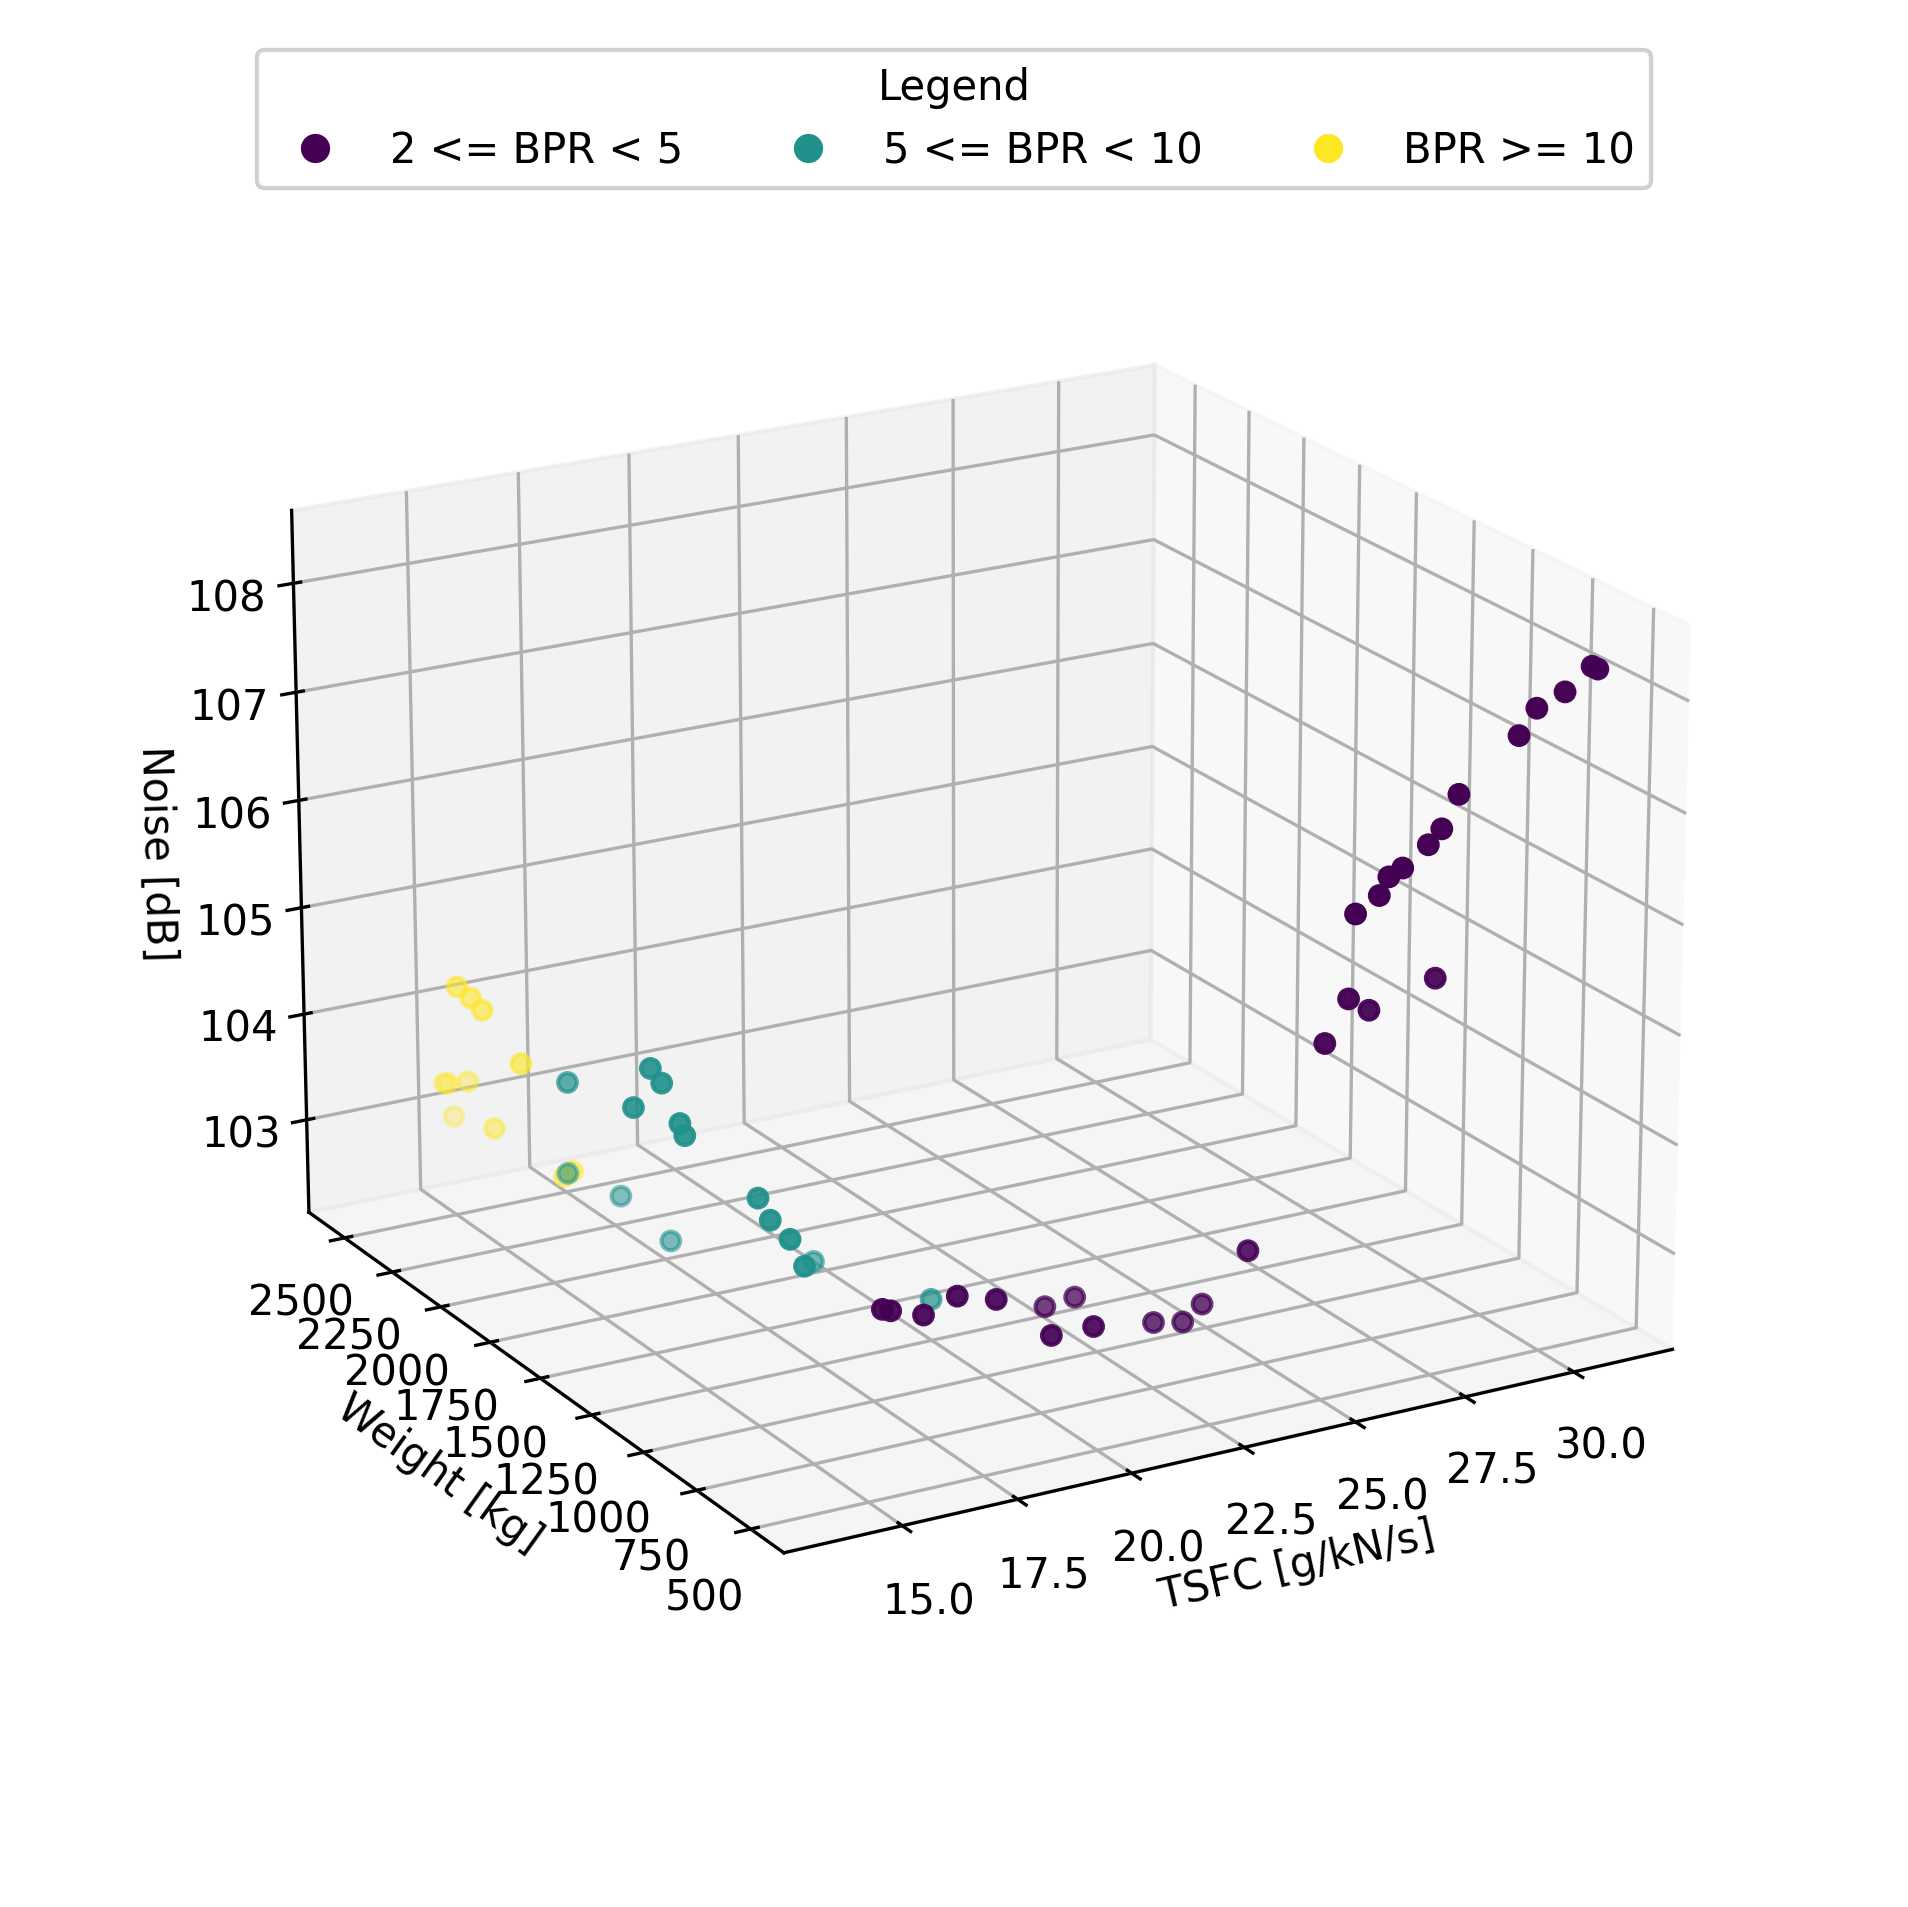

In [44]:

# Plot Pareto front
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(8, 8), dpi=300)

df_results_filtered = df_results[df_results['rpm_shaft_hp'] > df_results['rpm_shaft_ip']]

# 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

ax = fig.add_subplot(111, projection='3d')
scatter_real = ax.scatter3D(df_results_filtered['TSFC'], df_results_filtered['Weight'], df_results_filtered['Noise'], c=df_results_filtered['BPR_Class'].astype('category').cat.codes)

ax.set_xlabel('TSFC [g/kN/s]')
ax.set_ylabel('Weight [kg]')
ax.set_zlabel('Noise [dB]')

# Change angle for better visualization
ax.view_init(elev=20, azim=-120)

ax.set_box_aspect(None, zoom=0.85)

legend1 = ax.legend(*[scatter_real.legend_elements()[0],['2 <= BPR < 5','5 <= BPR < 10','BPR >= 10']], 
                    title="Legend", loc='upper center', ncol=3)
ax.add_artist(legend1)

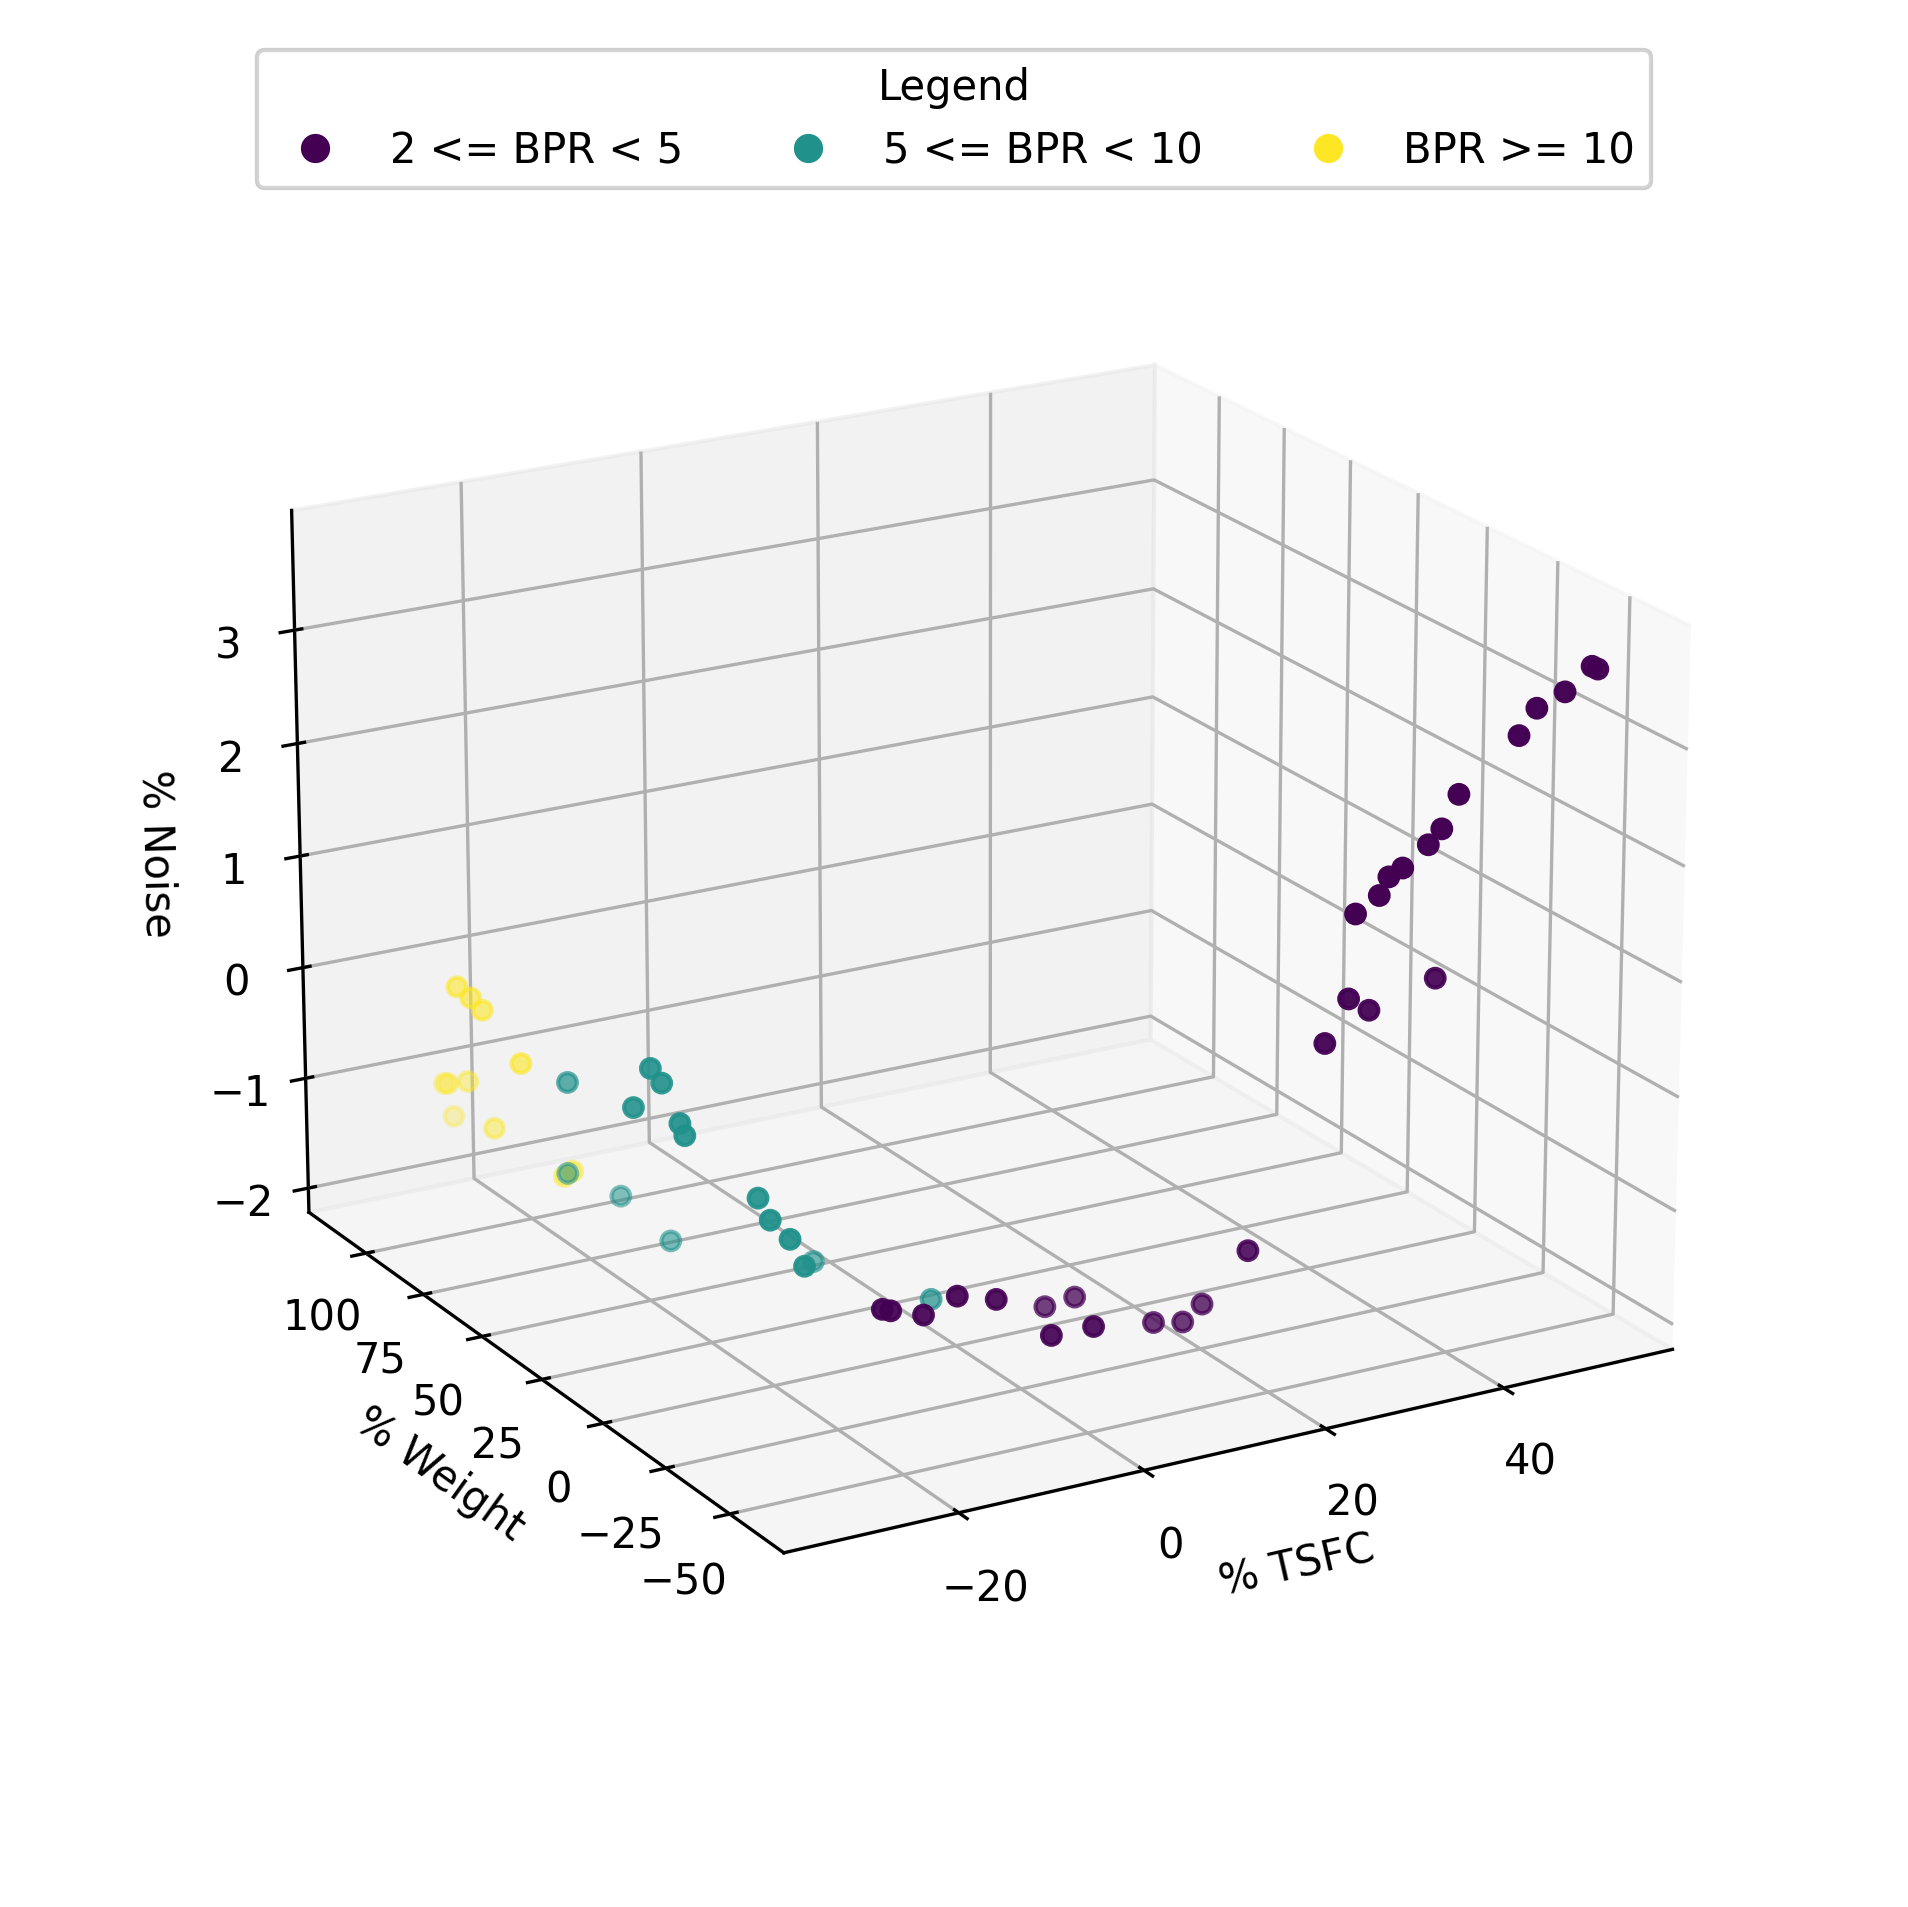

In [42]:
# Plot Pareto front
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(8, 8), dpi=300)

df_results_filtered = df_results[df_results['rpm_shaft_hp'] > df_results['rpm_shaft_ip']]

# 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

ax = fig.add_subplot(111, projection='3d')

TSFC_normalized = (df_results_filtered['TSFC'] - df_results_filtered['TSFC'].min()) / (df_results_filtered['TSFC'].max() - df_results_filtered['TSFC'].min())
Weight_normalized = (df_results_filtered['TSFC'] - df_results_filtered['TSFC'].min()) / (df_results_filtered['TSFC'].max() - df_results_filtered['TSFC'].min())
Noise_normalized = (df_results_filtered['Noise'] - df_results_filtered['Noise'].min()) / (df_results_filtered['Noise'].max() - df_results_filtered['Noise'].min())

TSFC_mean = df_results_filtered['TSFC'].mean()
Weight_mean = df_results_filtered['Weight'].mean()
Noise_mean = df_results_filtered['Noise'].mean()

TSFC_percent_diff = (df_results_filtered['TSFC'] - TSFC_mean) / TSFC_mean * 100
Weight_percent_diff = (df_results_filtered['Weight'] - Weight_mean) / Weight_mean * 100
Noise_percent_diff = (df_results_filtered['Noise'] - Noise_mean) / Noise_mean * 100

scatter = ax.scatter3D(TSFC_percent_diff, Weight_percent_diff, Noise_percent_diff, c=df_results_filtered['BPR_Class'].astype('category').cat.codes)
legend1 = ax.legend(*[scatter.legend_elements()[0],['2 <= BPR < 5','5 <= BPR < 10','BPR >= 10']], 
                    title="Legend", loc='upper center', ncol=3)
ax.add_artist(legend1)

ax.set_xlabel('% TSFC')
ax.set_ylabel('% Weight')
ax.set_zlabel('% Noise')

# Change angle for better visualization
ax.view_init(elev=20, azim=-120)

ax.set_box_aspect(None, zoom=0.85)

# 2. Get the current limits of the plot to know how long to draw the axes
xlim = ax.get_xlim()
ylim = ax.get_ylim()
zlim = ax.get_zlim()

# Set axis center to (0,0,0)


In [37]:
scatter.legend_elements()[0]

In [26]:
print(ax.spine)

AttributeError: 'Axes3D' object has no attribute 'spine'

In [14]:
result_X_filtered = df_results_filtered[free_dv_names].values

for dv in result_X_filtered:
    dv_adjusted = [adjust_dv_type(dv_i, dv_type) for dv_i, dv_type in zip(dv, free_dv_types)]
    
    architecture, imputed_dv = architecting_problem.generate_architecture(dv_adjusted)
    
    imputed_dv_dict = {des_var: value for des_var, value in zip(free_dv_names, imputed_dv)}
    
    print('Imputed design vector: %r' % imputed_dv_dict)
    
    design_vector, objectives, constraints, metrics = architecting_problem.evaluate(imputed_dv)
    
    break

Imputed design vector: {'bpr': 12.39227686640752, 'fpr': 1.4506071698495977, 'opr': 55.65242961845452, 'pr_compressor_ip': 0.28567976821456637, 'pr_compressor_lp': 0, 'rpm_shaft_hp': 11759.34887500935, 'rpm_shaft_ip': 10965.271828631136, 'rpm_shaft_lp': 10500.0, 'gear_ratio': 3.0, 'far': 0.025, 'eb_hb_total': 0.025, 'eb_hbi_frac_w': 0.0006250000000000001, 'eb_hbl_frac_w': 0.0, 'eb_ih_total': 0.0, 'eb_ihi_frac_w': 0.0, 'eb_ihl_frac_w': 0.0, 'eb_li_total': 0, 'eb_lii_frac_w': 0, 'eb_lil_frac_w': 0, 'ab_hpc_total': 0.0, 'ab_hi_frac_w': 0.0, 'ab_hl_frac_w': 0.0, 'ab_ipc_total': 0.0, 'ab_ii_frac_w': 0.0, 'ab_il_frac_w': 0.0, 'ab_lpc_total': 0, 'ab_li_frac_w': 0, 'ab_ll_frac_w': 0, 'ic_location': 0, 'radius': 0.030000000000000002, 'length': 0.255, 'number': 0}
